# Analyse Exploratoire

### Import des modules

In [138]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

### Analyse Exploratoire

In [139]:
building_consumption = pd.read_csv('2016_Building_Energy_Benchmarking.csv')

In [140]:
# On regarde comment un batiment est défini dans ce jeu de données 
building_consumption.head()

,OSEBuildingID,DataYear,BuildingType,PrimaryPropertyType,PropertyName,Address,City,State,ZipCode,TaxParcelIdentificationNumber,...,Electricity(kWh),Electricity(kBtu),NaturalGas(therms),NaturalGas(kBtu),DefaultData,Comments,ComplianceStatus,Outlier,TotalGHGEmissions,GHGEmissionsIntensity
0,1,2016,NonResidential,Hotel,Mayflower park hotel,405 Olive way,Seattle,WA,98101.0,0659000030,...,1.156514e+06,3946027.0,12764.52930,1276453.0,False,NaN,Compliant,NaN,249.98,2.83
1,2,2016,NonResidential,Hotel,Paramount Hotel,724 Pine street,Seattle,WA,98101.0,0659000220,...,9.504252e+05,3242851.0,51450.81641,5145082.0,False,NaN,Compliant,NaN,295.86,2.86
2,3,2016,NonResidential,Hotel,5673-The Westin Seattle,1900 5th Avenue,Seattle,WA,98101.0,0659000475,...,1.451544e+07,49526664.0,14938.00000,1493800.0,False,NaN,Compliant,NaN,2089.28,2.19
3,5,2016,NonResidential,Hotel,HOTEL MAX,620 STEWART ST,Seattle,WA,98101.0,0659000640,...,8.115253e+05,2768924.0,18112.13086,1811213.0,False,NaN,Compliant,NaN,286.43,4.67
4,8,2016,NonResidential,Hotel,WARWICK SEATTLE HOTEL (ID8),401 LENORA ST,Seattle,WA,98121.0,0659000970,...,1.573449e+06,5368607.0,88039.98438,8803998.0,False,NaN,Compliant,NaN,505.01,2.88


In [141]:
# On regarde le nombre de valeurs manquantes par colonne ainsi que leur type 
building_consumption.info()

<class 'pandas.DataFrame'>
RangeIndex: 3376 entries, 0 to 3375
Data columns (total 46 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   OSEBuildingID                    3376 non-null   int64  
 1   DataYear                         3376 non-null   int64  
 2   BuildingType                     3376 non-null   str    
 3   PrimaryPropertyType              3376 non-null   str    
 4   PropertyName                     3376 non-null   str    
 5   Address                          3376 non-null   str    
 6   City                             3376 non-null   str    
 7   State                            3376 non-null   str    
 8   ZipCode                          3360 non-null   float64
 9   TaxParcelIdentificationNumber    3376 non-null   str    
 10  CouncilDistrictCode              3376 non-null   int64  
 11  Neighborhood                     3376 non-null   str    
 12  Latitude                       

#### TERMINER L'ANALYSE EXPLORATOIRE 

A réaliser : 
- Une analyse descriptive des données, y compris une explication du sens des colonnes gardées, des arguments derrière la suppression de lignes ou de colonnes, des statistiques descriptives et des visualisations pertinentes.

In [142]:
# Dimensions du jeu de données (lignes, colonnes)
print(f"Dimensions initiales : {building_consumption.shape}")

Dimensions initiales : (3376, 46)


In [143]:
# Lister toutes les colonnes pour repérer celles liées au type de bâtiment
print("Colonnes disponibles dans le jeu de données :")
print(building_consumption.columns.tolist())

Colonnes disponibles dans le jeu de données :
['OSEBuildingID', 'DataYear', 'BuildingType', 'PrimaryPropertyType', 'PropertyName', 'Address', 'City', 'State', 'ZipCode', 'TaxParcelIdentificationNumber', 'CouncilDistrictCode', 'Neighborhood', 'Latitude', 'Longitude', 'YearBuilt', 'NumberofBuildings', 'NumberofFloors', 'PropertyGFATotal', 'PropertyGFAParking', 'PropertyGFABuilding(s)', 'ListOfAllPropertyUseTypes', 'LargestPropertyUseType', 'LargestPropertyUseTypeGFA', 'SecondLargestPropertyUseType', 'SecondLargestPropertyUseTypeGFA', 'ThirdLargestPropertyUseType', 'ThirdLargestPropertyUseTypeGFA', 'YearsENERGYSTARCertified', 'ENERGYSTARScore', 'SiteEUI(kBtu/sf)', 'SiteEUIWN(kBtu/sf)', 'SourceEUI(kBtu/sf)', 'SourceEUIWN(kBtu/sf)', 'SiteEnergyUse(kBtu)', 'SiteEnergyUseWN(kBtu)', 'SteamUse(kBtu)', 'Electricity(kWh)', 'Electricity(kBtu)', 'NaturalGas(therms)', 'NaturalGas(kBtu)', 'DefaultData', 'Comments', 'ComplianceStatus', 'Outlier', 'TotalGHGEmissions', 'GHGEmissionsIntensity']


In [144]:
# Observer les valeurs uniques dans 'BuildingType'
print("\nRépartition de la colonne 'BuildingType' :")
print(building_consumption['BuildingType'].value_counts())


Répartition de la colonne 'BuildingType' :
BuildingType
NonResidential          1460
Multifamily LR (1-4)    1018
Multifamily MR (5-9)     580
Multifamily HR (10+)     110
SPS-District K-12         98
Nonresidential COS        85
Campus                    24
Nonresidential WA          1
Name: count, dtype: int64


In [145]:
# Liste des types non-résidentiels identifiés à l'action précédente
non_residential_types = [
    'NonResidential', 
    'SPS-District K-12', 
    'Nonresidential COS', 
    'Campus', 
    'Nonresidential WA'
]

In [146]:
# Filtrage
df_clean = building_consumption[building_consumption['BuildingType'].isin(non_residential_types)].copy()

In [147]:
# Traçabilité du volume de données avant / après
n_avant = len(building_consumption)
n_apres = len(df_clean)
print(f"Nombre initial de lignes : {n_avant}")
print(f"Nombre de lignes conservées (non-résidentiel) : {n_apres}")
print(f"Nombre de lignes supprimées : {n_avant - n_apres} ({((n_avant - n_apres) / n_avant) * 100:.1f}%)")

Nombre initial de lignes : 3376
Nombre de lignes conservées (non-résidentiel) : 1668
Nombre de lignes supprimées : 1708 (50.6%)


In [148]:
# Sélection des colonnes candidates pour la target
candidate_targets = [
    'SiteEnergyUse(kBtu)', 
    'SiteEnergyUseWN(kBtu)', 
    'SiteEUI(kBtu/sf)', 
    'SourceEUI(kBtu/sf)', 
    'TotalGHGEmissions'
]

### Analyse et sélection de la variable cible (Target)

**Définition :** Aux États-Unis, le kBtu sert d'unité commune standardisée pour additionner différentes sources d'énergie (électricité mesurée en kWh, gaz naturel mesuré en therms, et vapeur) dans un seul et même indicateur global.

Plusieurs colonnes du jeu de données mesurent la performance énergétique et environnementale des bâtiments :

* **`SiteEnergyUse(kBtu)`** : Consommation énergétique totale réelle mesurée sur site (toutes énergies confondues : électricité, gaz, vapeur).
* **`SiteEnergyUseWN(kBtu)`** : Consommation totale ajustée/normalisée selon les variations météorologiques (*Weather Normalized*).
* **`SiteEUI(kBtu/sf)`** : Intensité énergétique sur site par unité de surface ($\text{kBtu} / \text{sq ft}$).
* **`SourceEUI(kBtu/sf)`** : Intensité énergétique globale incluant les pertes de production et de transport de l'énergie.
* **`TotalGHGEmissions`** : Émissions totales de gaz à effet de serre (en tonnes métriques d'équivalent $\text{CO}_2$).

---
**Choix retenu :** **`SiteEnergyUseWN(kBtu)`** est sélectionnée comme cible principale. Ce choix permet de modéliser la performance énergétique intrinsèque et structurelle des bâtiments en s'affranchissant des anomalies climatiques spécifiques de l'année 2016.

In [149]:
# Affichage des statistiques descriptives
print("Statistiques descriptives des cibles candidates :")
print(df_clean[candidate_targets].describe().T[['count', 'mean', 'min', '50%', 'max']])

Statistiques descriptives des cibles candidates :
                        count          mean  min           50%           max
SiteEnergyUse(kBtu)    1666.0  8.437933e+06  0.0  2.554947e+06  8.739237e+08
SiteEnergyUseWN(kBtu)  1665.0  8.064790e+06  0.0  2.685146e+06  4.716139e+08
SiteEUI(kBtu/sf)       1665.0  7.215880e+01  0.0  5.190000e+01  8.344000e+02
SourceEUI(kBtu/sf)     1666.0  1.758299e+02  0.0  1.309500e+02  2.620000e+03
TotalGHGEmissions      1666.0  1.849733e+02 -0.8  4.958000e+01  1.687098e+04


In [150]:
# Vérification des valeurs manquantes
print("\nValeurs manquantes :")
print(df_clean[candidate_targets].isnull().sum())


Valeurs manquantes :
SiteEnergyUse(kBtu)      2
SiteEnergyUseWN(kBtu)    3
SiteEUI(kBtu/sf)         3
SourceEUI(kBtu/sf)       2
TotalGHGEmissions        2
dtype: int64


#### Analyse des statistiques descriptives de la cible

L'inspection descriptive de la colonne cible **`SiteEnergyUseWN(kBtu)`** met en évidence deux points critiques :

1. **Présence d'anomalies de mesure :** 
   - La valeur minimale est de **$0\text{ kBtu}$** (et $3$ valeurs manquantes `NaN` sont recensées).
   - Un bâtiment actif ne pouvant pas avoir une consommation nulle, ces lignes correspondent à des compteurs inactifs ou des bâtiments inoccupés et doivent être retirées pour ne pas fausser l'apprentissage.

2. **Forte asymétrie de distribution (*right-skewed*) :**
   - La médiane ($2{,}68 \times 10^6\text{ kBtu}$) est très inférieure à la moyenne ($8{,}06 \times 10^6\text{ kBtu}$).
   - L'écart avec le maximum ($471{,}61 \times 10^6\text{ kBtu}$) indique une forte concentration sur les petites/moyennes consommations et une traîne vers la droite due à quelques très grands complexes.

---
**Décision :** Suppression des lignes ayant une cible manquante ou inférieure/égale à $0$ avant de poursuivre l'exploration.

In [151]:
# Suivi avant suppression
n_avant_cible = len(df_clean)

# Filtrage des consommations normalisées strictement positives
df_clean = df_clean[df_clean['SiteEnergyUseWN(kBtu)'].notnull() & (df_clean['SiteEnergyUseWN(kBtu)'] > 0)].copy()

# Traçabilité
n_apres_cible = len(df_clean)
print(f"Nombre de lignes avant nettoyage de la cible : {n_avant_cible}")
print(f"Nombre de lignes conservées (cible > 0) : {n_apres_cible}")
print(f"Lignes supprimées (nulles ou NaN) : {n_avant_cible - n_apres_cible}")

Nombre de lignes avant nettoyage de la cible : 1668
Nombre de lignes conservées (cible > 0) : 1640
Lignes supprimées (nulles ou NaN) : 28


#### Analyse des valeurs manquantes par colonne

Afin de ne pas perdre de données en supprimant aveuglément des lignes, nous évaluons le taux de valeurs manquantes (*NaN*) pour chaque colonne du jeu de données filtré.

**Objectifs de cette analyse :**
* Identifier les colonnes quasi vides (ex. > 50 % ou 90 % de valeurs manquantes) qui ne pourront pas être imputées de manière fiable.
* Comprendre l'origine métier des valeurs manquantes (ex. usages secondaires ou tertiaires inexistants pour un bâtiment à usage unique).
* Déterminer quelles colonnes écarter en amont afin de préserver un volume maximal de bâtiments pour l'entraînement des modèles.

In [152]:
# 1. Calcul du nombre et du pourcentage de valeurs manquantes
missing_counts = df_clean.isnull().sum()
missing_pct = (missing_counts / len(df_clean)) * 100

# 2. Création d'un DataFrame récapitulatif trié
missing_df = pd.DataFrame({
    'Valeurs Manquantes': missing_counts,
    'Pourcentage (%)': missing_pct.round(2)
})

# 3. Affichage des colonnes ayant au moins une valeur manquante
print("Colonnes présentant des valeurs manquantes :")
print(missing_df[missing_df['Valeurs Manquantes'] > 0].sort_values(by='Pourcentage (%)', ascending=False))

Colonnes présentant des valeurs manquantes :
                                 Valeurs Manquantes  Pourcentage (%)
Comments                                       1640           100.00
Outlier                                        1623            98.96
YearsENERGYSTARCertified                       1544            94.15
ThirdLargestPropertyUseType                    1288            78.54
ThirdLargestPropertyUseTypeGFA                 1288            78.54
SecondLargestPropertyUseType                    790            48.17
SecondLargestPropertyUseTypeGFA                 790            48.17
ENERGYSTARScore                                 554            33.78
ZipCode                                          16             0.98
LargestPropertyUseTypeGFA                         4             0.24
LargestPropertyUseType                            4             0.24


#### Sélection des variables et suppression des colonnes non pertinentes

Nous nettoyons les colonnes du jeu de données selon 3 critères :
1. **Métadonnées et identifiants :** Informations administratives ou textuelles non généralisables (`OSEBuildingID`, `Address`, `Comments`, etc.).
2. **Colonnes trop lacunaires :** Usages secondaires/tertiaires et certifications peu renseignées.
3. **Fuite d'information (*Data Leakage*) :** Sous-consommations détaillées (électricité, gaz) et intensités énergétiques calculées à partir de la cible.

In [153]:
# Liste des colonnes à écarter
cols_to_drop = [
    # Métadonnées & Identifiants
    'OSEBuildingID', 'DataYear', 'PropertyName', 'Address', 'City', 'State', 
    'TaxParcelIdentificationNumber', 'Comments', 'Outlier', 'YearsENERGYSTARCertified',
    # Usages secondaires/tertiaires très incomplets
    'SecondLargestPropertyUseType', 'SecondLargestPropertyUseTypeGFA',
    'ThirdLargestPropertyUseType', 'ThirdLargestPropertyUseTypeGFA',
    # Sous-consommations et métriques dérivées (Data Leakage)
    'Electricity(kWh)', 'Electricity(kBtu)', 'NaturalGas(therms)', 'NaturalGas(kBtu)', 
    'SteamUse(kBtu)', 'SiteEnergyUse(kBtu)', 'SiteEUI(kBtu/sf)', 'SiteEUIWN(kBtu/sf)', 
    'SourceEUI(kBtu/sf)', 'SourceEUIWN(kBtu/sf)'
]

# Suppression des colonnes
df_model = df_clean.drop(columns=[c for c in cols_to_drop if c in df_clean.columns]).copy()

print(f"Nombre de colonnes initiales : {df_clean.shape[1]}")
print(f"Nombre de colonnes restantes pour l'analyse : {df_model.shape[1]}")
print("\nColonnes conservées :")
print(df_model.columns.tolist())

Nombre de colonnes initiales : 46
Nombre de colonnes restantes pour l'analyse : 22

Colonnes conservées :
['BuildingType', 'PrimaryPropertyType', 'ZipCode', 'CouncilDistrictCode', 'Neighborhood', 'Latitude', 'Longitude', 'YearBuilt', 'NumberofBuildings', 'NumberofFloors', 'PropertyGFATotal', 'PropertyGFAParking', 'PropertyGFABuilding(s)', 'ListOfAllPropertyUseTypes', 'LargestPropertyUseType', 'LargestPropertyUseTypeGFA', 'ENERGYSTARScore', 'SiteEnergyUseWN(kBtu)', 'DefaultData', 'ComplianceStatus', 'TotalGHGEmissions', 'GHGEmissionsIntensity']


#### Visualisation de la distribution de la variable cible

Nous comparons la distribution brute de `SiteEnergyUseWN(kBtu)` avec sa transformation logarithmique `log1p` :
* **Distribution brute :** Permet d'observer l'étalement réel des valeurs et l'écrasement visuel provoqué par les très grands bâtiments.
* **Transformation Log :** Permet de stabiliser la variance et de vérifier si la cible adopte une forme en cloche plus symétrique, idéale pour les algorithmes d'apprentissage supervisé.

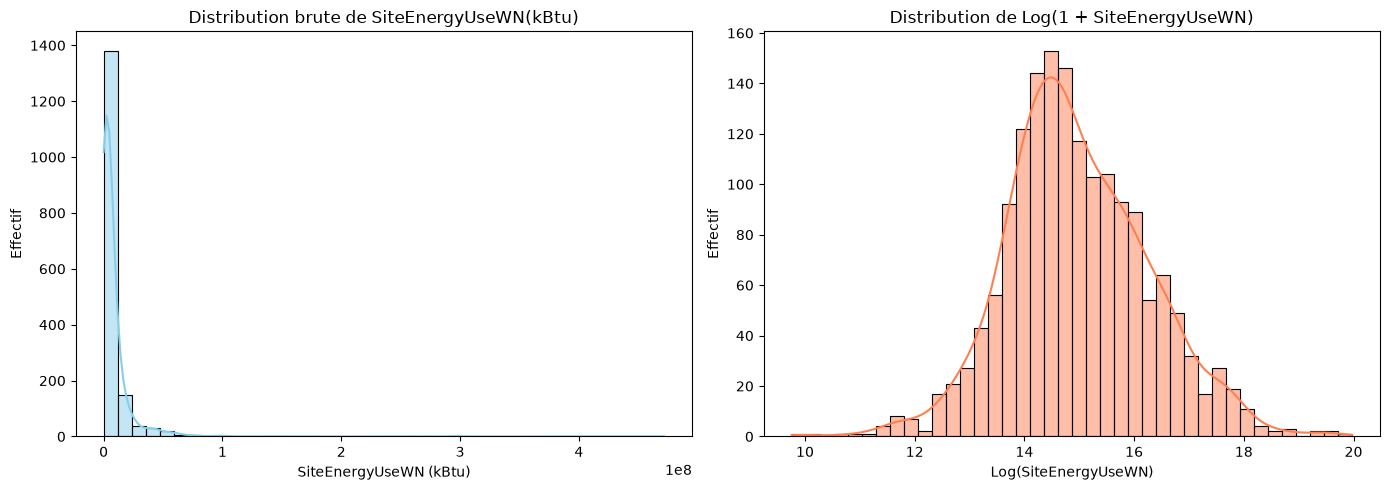

In [154]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 1. Distribution brute
sns.histplot(df_model['SiteEnergyUseWN(kBtu)'], bins=40, kde=True, ax=axes[0], color='skyblue')
axes[0].set_title("Distribution brute de SiteEnergyUseWN(kBtu)")
axes[0].set_xlabel("SiteEnergyUseWN (kBtu)")
axes[0].set_ylabel("Effectif")

# 2. Distribution transformée en Logarithme
sns.histplot(np.log1p(df_model['SiteEnergyUseWN(kBtu)']), bins=40, kde=True, ax=axes[1], color='coral')
axes[1].set_title("Distribution de Log(1 + SiteEnergyUseWN)")
axes[1].set_xlabel("Log(SiteEnergyUseWN)")
axes[1].set_ylabel("Effectif")

plt.tight_layout()
plt.show()

In [155]:
# Calcul mathématique des coefficients d'asymétrie (Skewness)
skew_brute = df_model['SiteEnergyUseWN(kBtu)'].skew()
skew_log = np.log1p(df_model['SiteEnergyUseWN(kBtu)']).skew()

print(f"Skewness de la cible brute : {skew_brute:.2f}")
print(f"Skewness de la cible transformée en log : {skew_log:.2f}")

Skewness de la cible brute : 11.24
Skewness de la cible transformée en log : 0.22


#### Interprétation de la distribution de la cible

* **Distribution brute :** Présente une très forte asymétrie à droite (*skewness* de $11{,}24$). Les valeurs extrêmes écrasent les données et risquent de biaiser l'apprentissage des modèles.
* **Distribution Log :** Le passage au logarithme $\log(1 + \text{SiteEnergyUseWN})$ régularise la distribution en une forme gaussienne symétrique (*skewness* de $0{,}22$). 

> **Décision :** La cible sera entraînée sous sa forme logarithmique $\log(1 + y)$ pour stabiliser la variance des résidus et améliorer les performances des algorithmes de régression.

#### Analyse bivariée : Relation Surface Totale vs Consommation Énergétique

Nous étudions le lien entre la dimension structurelle principale du bâtiment (**`PropertyGFATotal`** - Gross Floor Area totale) et sa consommation énergétique normalisée (**`SiteEnergyUseWN(kBtu)`**).

* **Échelle Log-Log :** Permet d'observer la linéarité du lien sur plusieurs ordres de grandeur de surfaces sans écrasement graphique.
* **Segmentation par type de bâtiment :** La couleur par **`BuildingType`** permet d'identifier des disparités d'intensité énergétique selon la catégorie du bien (ex. campus, écoles, bureaux standard).

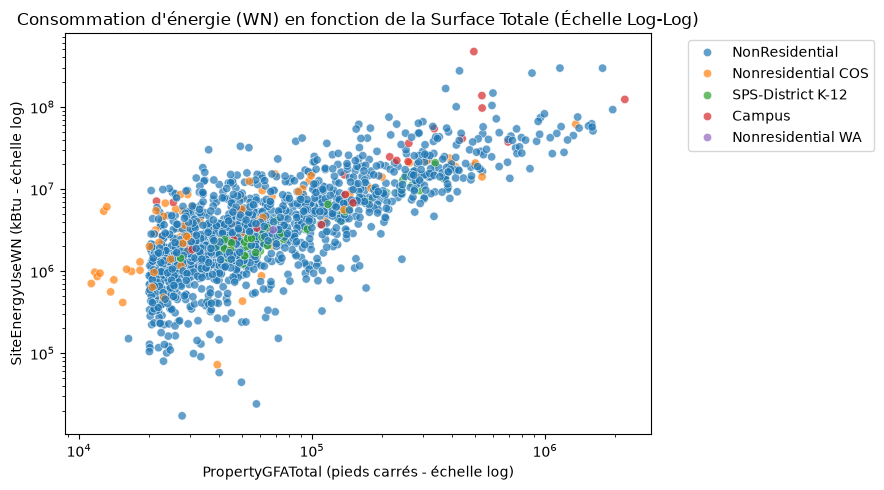

Coefficient de corrélation linéaire (Pearson) Surface Totale vs Cible brute : 0.59
Coefficient de corrélation linéaire (Pearson) Log(Surface) vs Log(Cible) : 0.76


In [162]:
plt.figure(figsize=(9, 5))

# Nuage de points en échelle Log-Log
sns.scatterplot(
    data=df_model, 
    x='PropertyGFATotal', 
    y='SiteEnergyUseWN(kBtu)', 
    hue='BuildingType', 
    alpha=0.7
)

plt.xscale('log')
plt.yscale('log')
plt.title("Consommation d'énergie (WN) en fonction de la Surface Totale (Échelle Log-Log)")
plt.xlabel("PropertyGFATotal (pieds carrés - échelle log)")
plt.ylabel("SiteEnergyUseWN (kBtu - échelle log)")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()

# Calcul du coefficient de corrélation linéaire (Pearson)
corr_surface = df_model['PropertyGFATotal'].corr(df_model['SiteEnergyUseWN(kBtu)'])
print(f"Coefficient de corrélation linéaire (Pearson) Surface Totale vs Cible brute : {corr_surface:.2f}")

# Corrélation sur les variables transformées en Log
corr_surface_log = np.log1p(df_model['PropertyGFATotal']).corr(np.log1p(df_model['SiteEnergyUseWN(kBtu)']))
print(f"Coefficient de corrélation linéaire (Pearson) Log(Surface) vs Log(Cible) : {corr_surface_log:.2f}")

#### Interprétation de la relation Surface Totale vs Consommation Énergétique

* **Corrélation linéaire forte en Log-Log ($r = 0{,}76$) :** La surface totale (`PropertyGFATotal`) constitue le premier déterminant mécanique de la consommation énergétique globale. La transformation logarithmique linéarise nettement cette relation (gain de $0{,}59$ à $0{,}76$).
* **Dispersion à surface équivalente :** L'étalement vertical pour une même taille de bâtiment met en évidence l'impact majeur d'autres facteurs (type d'activité, intensité d'usage, année de construction, mix d'équipements).

> **Conclusion :** `PropertyGFATotal` est une feature clé incontournable, mais elle doit être complétée par les caractéristiques d'usage et d'âge du bâtiment pour une prédiction précise.

#### Analyse bivariée : Influence de l'usage principal (PrimaryPropertyType) sur la consommation

Nous étudions l'impact du type d'activité du bâtiment (**`PrimaryPropertyType`**) sur la consommation énergétique (**`SiteEnergyUseWN(kBtu)`**)
* **Boîtes à moustaches (Boxplots) :** Permettent de comparer la médiane, l'écart interquartile (dispersion) et les ordres de grandeur de consommation pour chaque catégorie d'usage.
* **Échelle logarithmique :** Utilisée pour visualiser l'ensemble des catégories sans écrasement par les plus gros complexes.
* **Tri par médiane :** Les types de propriétés sont ordonnés de manière croissante selon leur niveau de consommation médian.

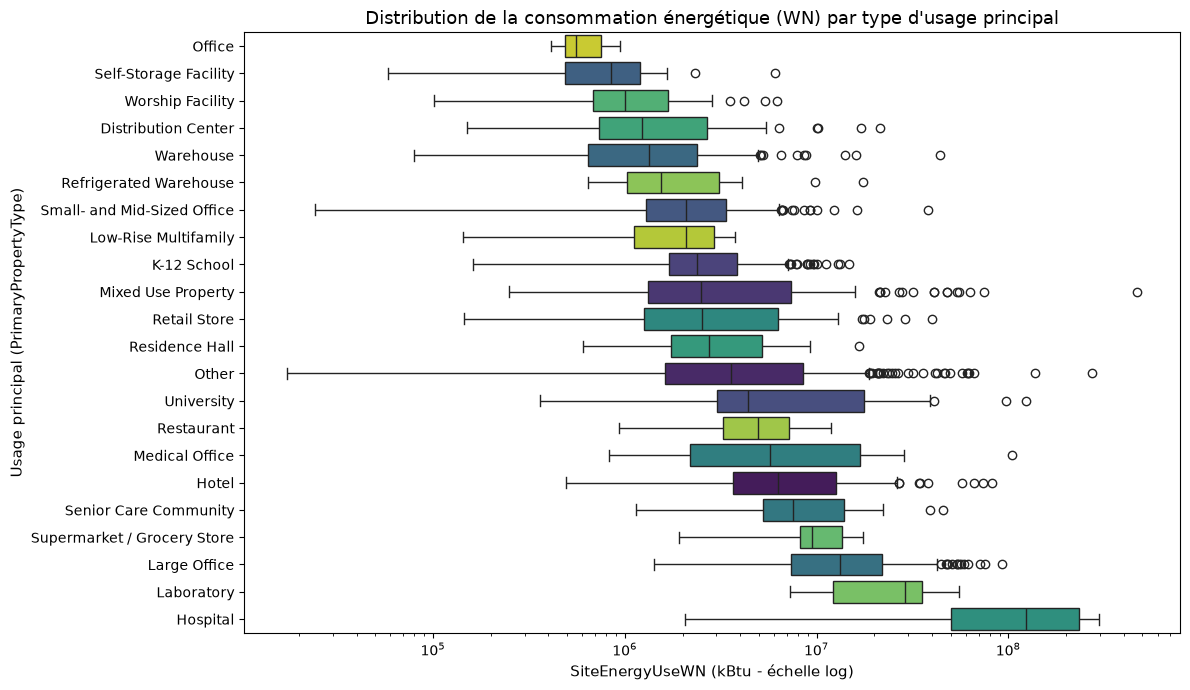

In [164]:
plt.figure(figsize=(12, 7))

# Ordonner les types d'usage selon la médiane de consommation
order_types = df_model.groupby('PrimaryPropertyType')['SiteEnergyUseWN(kBtu)'].median().sort_values().index

# Tracé sans warning
sns.boxplot(
    data=df_model,
    y='PrimaryPropertyType',
    x='SiteEnergyUseWN(kBtu)',
    order=order_types,
    hue='PrimaryPropertyType',
    palette='viridis',
    legend=False
)

plt.xscale('log')
plt.title("Distribution de la consommation énergétique (WN) par type d'usage principal", fontsize=13)
plt.xlabel("SiteEnergyUseWN (kBtu - échelle log)", fontsize=11)
plt.ylabel("Usage principal (PrimaryPropertyType)", fontsize=11)

plt.tight_layout()
plt.show()

#### Interprétation : Influence du type d'usage principal (PrimaryPropertyType)

* **Gradient de consommation marqué :** La médiane de consommation varie de plus de deux ordres de grandeur (d'environ $8 \times 10^5\text{ kBtu}$ pour les entrepôts/lieux de culte à plus de $10^8\text{ kBtu}$ pour les hôpitaux).
* **Intensité d'exploitation :** Les établissements fonctionnant en continu avec des équipements techniques lourds (*Hospital*, *Laboratory*, *Supermarket*, *Large Office*) présentent les consommations les plus élevées.
* **Hétérogénéité intra-catégorie :** La dispersion au sein des catégories mixtes ou hôtelières reflète des différences importantes de surface et d'occupation.

> **Décision :** La variable `PrimaryPropertyType` est un prédicteur catégoriel majeur qui devra être intégré et encodé dans notre pipeline de modélisation.

#### Matrice de corrélation des variables numériques

Nous calculons la matrice des corrélations linéaires (Pearson) entre les variables quantitatives physiques (`PropertyGFATotal`, `PropertyGFABuilding(s)`, `PropertyGFAParking`, `LargestPropertyUseTypeGFA`, `NumberofFloors`, `NumberofBuildings`, `YearBuilt`), le score environnemental (`ENERGYSTARScore`) et la cible sous sa forme transformée ($\log(1 + \text{SiteEnergyUseWN})$).

**Objectifs :**
1. **Identifier les variables les plus corrélées à la cible.**
2. **Repérer les redondances (multicollinéarité) entre les différentes mesures de surface.**

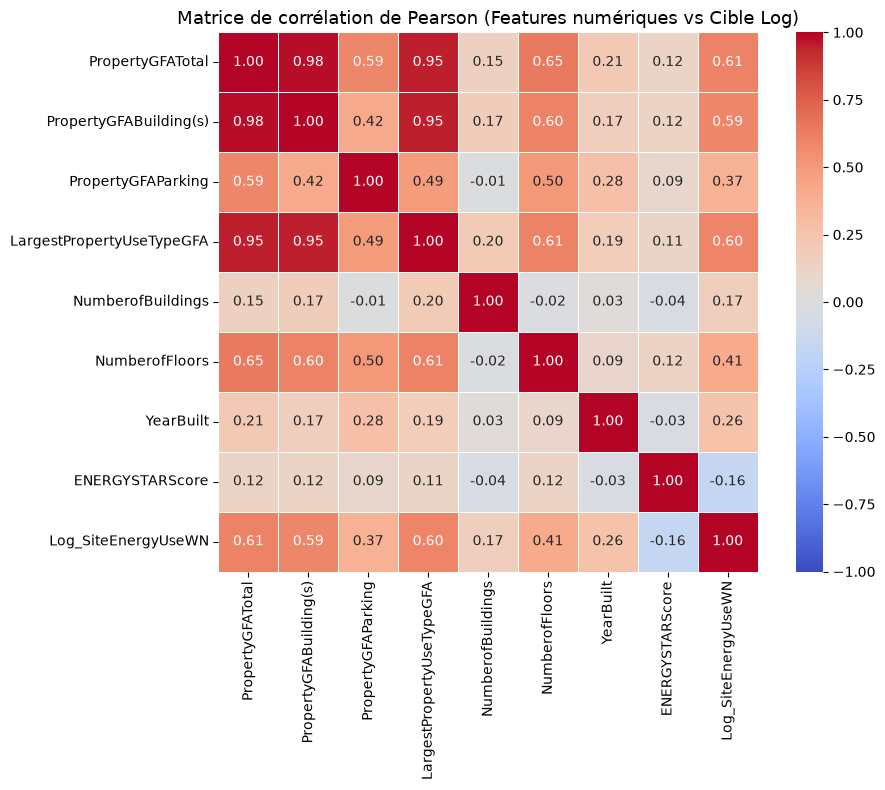

In [165]:
# 1. Sélection des features numériques d'intérêt + cible log
df_corr = df_model[[
    'PropertyGFATotal', 
    'PropertyGFABuilding(s)', 
    'PropertyGFAParking', 
    'LargestPropertyUseTypeGFA', 
    'NumberofBuildings', 
    'NumberofFloors', 
    'YearBuilt', 
    'ENERGYSTARScore'
]].copy()

# Ajout de la cible en échelle Log
df_corr['Log_SiteEnergyUseWN'] = np.log1p(df_model['SiteEnergyUseWN(kBtu)'])

# 2. Calcul de la matrice de corrélation
corr_matrix = df_corr.corr()

# 3. Tracé de la Heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(
    corr_matrix, 
    annot=True, 
    fmt=".2f", 
    cmap='coolwarm', 
    vmin=-1, 
    vmax=1, 
    square=True, 
    linewidths=0.5
)

plt.title("Matrice de corrélation de Pearson (Features numériques vs Cible Log)", fontsize=13)
plt.tight_layout()
plt.show()

#### Interprétation de la matrice de corrélation des variables numériques

1. **Variables les plus corrélées à la cible (`Log_SiteEnergyUseWN`) :**
   * **Dimensions physiques globales :** `PropertyGFATotal` ($r = 0{,}61$), `LargestPropertyUseTypeGFA` ($r = 0{,}60$) et `PropertyGFABuilding(s)` ($r = 0{,}59$) présentent les plus fortes corrélations linéaires positives avec la consommation d'énergie.
   * **Hauteur du bâtiment :** `NumberofFloors` affiche une corrélation modérée positive ($r = 0{,}41$).
   * **Surfaces annexes et âge :** `PropertyGFAParking` ($r = 0{,}37$) et `YearBuilt` ($r = 0{,}26$) ont un lien modéré avec la cible.
   * **Performance énergétique :** `ENERGYSTARScore` présente une corrélation négative faible ($r = -0{,}16$), cohérente avec le métier (un score plus élevé reflète une meilleure efficacité énergétique).

2. **Mise en évidence de la multicollinéarité (redondances) :**
   * Les différentes mesures de surface sont quasi parfaitement corrélées entre elles ($r \ge 0{,}95$) :
     * `PropertyGFATotal` $\leftrightarrow$ `PropertyGFABuilding(s)` : $r = 0{,}98$
     * `PropertyGFATotal` $\leftrightarrow$ `LargestPropertyUseTypeGFA` : $r = 0{,}95$
     * `PropertyGFABuilding(s)` $\leftrightarrow$ `LargestPropertyUseTypeGFA` : $r = 0{,}95$

> **Décision pour la modélisation :**
> * Afin d'éviter l'instabilité des modèles linéaires liée à la multicollinéarité, nous conserverons une mesure de surface de référence (`PropertyGFATotal`) et pourrons transformer les autres en ratios (ex. proportion de surface de parking).
> * Les modèles à base d'arbres (*Random Forest*, *XGBoost*) seront particulièrement adaptés pour capter les relations non linéaires avec `YearBuilt` et `ENERGYSTARScore`.

#### Analyse exploratoire de la seconde cible : TotalGHGEmissions (Émissions de GES)

Nous explorons la distribution de la variable **`TotalGHGEmissions`** (exprimée en tonnes métriques d'équivalent CO2) ainsi que sa relation avec la surface totale (**`PropertyGFATotal`**) :
1. **Distribution brute vs transformée en log ($\log(1+y)$) :** Vérification de l'asymétrie et du comportement de la distribution.
2. **Corrélation et nuage de points Log-Log :** Mesure du lien entre la surface et les émissions de GES.

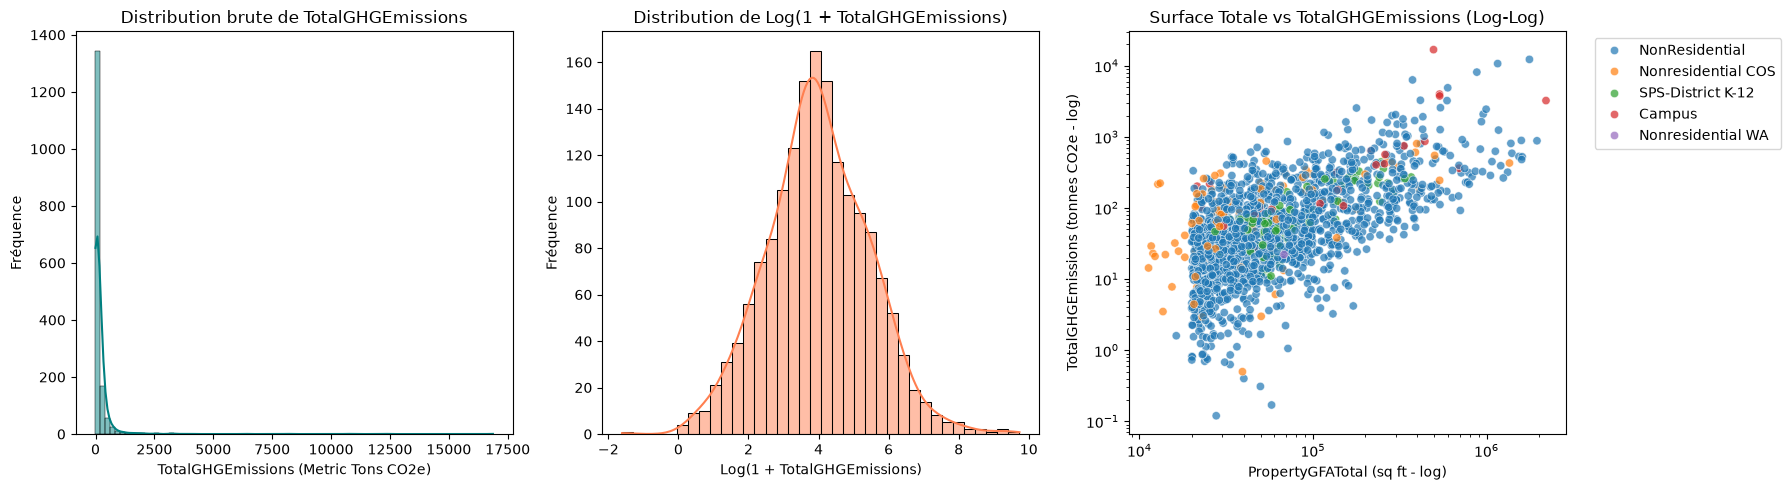

Corrélation linéaire Surface vs TotalGHGEmissions (brute) : 0.42
Corrélation linéaire Log(Surface) vs Log(TotalGHGEmissions) : 0.61


In [166]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. Histogramme de la distribution brute
sns.histplot(df_model['TotalGHGEmissions'], kde=True, ax=axes[0], color='teal')
axes[0].set_title("Distribution brute de TotalGHGEmissions")
axes[0].set_xlabel("TotalGHGEmissions (Metric Tons CO2e)")
axes[0].set_ylabel("Fréquence")

# 2. Histogramme après transformation Logarithmique
log_ghg = np.log1p(df_model['TotalGHGEmissions'])
sns.histplot(log_ghg, kde=True, ax=axes[1], color='coral')
axes[1].set_title("Distribution de Log(1 + TotalGHGEmissions)")
axes[1].set_xlabel("Log(1 + TotalGHGEmissions)")
axes[1].set_ylabel("Fréquence")

# 3. Nuage de points Log-Log (Surface vs Émissions GHG)
sns.scatterplot(
    data=df_model, 
    x='PropertyGFATotal', 
    y='TotalGHGEmissions', 
    hue='BuildingType', 
    alpha=0.7,
    ax=axes[2]
)
axes[2].set_xscale('log')
axes[2].set_yscale('log')
axes[2].set_title("Surface Totale vs TotalGHGEmissions (Log-Log)")
axes[2].set_xlabel("PropertyGFATotal (sq ft - log)")
axes[2].set_ylabel("TotalGHGEmissions (tonnes CO2e - log)")
axes[2].legend(bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()

# Corrélations de Pearson
corr_ghg_raw = df_model['PropertyGFATotal'].corr(df_model['TotalGHGEmissions'])
corr_ghg_log = np.log1p(df_model['PropertyGFATotal']).corr(log_ghg)

print(f"Corrélation linéaire Surface vs TotalGHGEmissions (brute) : {corr_ghg_raw:.2f}")
print(f"Corrélation linéaire Log(Surface) vs Log(TotalGHGEmissions) : {corr_ghg_log:.2f}")

#### Interprétation de l'analyse exploratoire sur TotalGHGEmissions

* **Forte asymétrie à droite :** La distribution brute des émissions de GES est très étalée et dominée par quelques valeurs extrêmes.
* **Validation de la transformation logarithmique :** L'application de $\log(1+y)$ permet d'obtenir une distribution symétrique (proche d'une loi normale), indispensable pour stabiliser les résidus des modèles de régression.
* **Lien avec la surface, le mix énergétique et le type d'usage :** Bien que la surface totale soit corrélée positivement aux émissions, la grande dispersion verticale à surface égale s'explique par :
  1. **Le mix énergétique :** L'intensité carbone dépend du recours au gaz/vapeur par rapport à l'électricité (largement décarbonée à Seattle).
  2. **Le type d'usage du bâtiment (`PrimaryPropertyType`) :** Les activités à forte intensité continue ou nécessitant des procédés thermiques lourds (hôpitaux, restauration, hôtels) émettent nettement plus de GES à surface équivalente que des bureaux ou des entrepôts.

> **Conclusion :** Tout comme pour `SiteEnergyUseWN`, la cible `TotalGHGEmissions` devra être prédite sous sa forme logarithmique, et le type d'activité sera une variable explicative déterminante.

# Modélisation 

### Import des modules 

In [156]:
#Selection
from sklearn.model_selection import (
    train_test_split,
    GridSearchCV, 
    cross_validate,
)
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error 
from sklearn.inspection import permutation_importance

#Preprocess
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import LabelEncoder, OneHotEncoder, StandardScaler

#Modèles
from sklearn.dummy import DummyRegressor
from sklearn.linear_model import LinearRegression
from sklearn.svm import SVR
from sklearn.ensemble import RandomForestRegressor


### Feature Engineering

A réaliser : Enrichir le jeu de données actuel avec de nouvelles features issues de celles existantes. 

In [157]:
# CODE FEATURE ENGINEERING

### Préparation des features pour la modélisation

A réaliser :
* Si ce n'est pas déjà fait, supprimer toutes les colonnes peu pertinentes pour la modélisation.
* Tracer la distribution de la cible pour vous familiariser avec l'ordre de grandeur. En cas d'outliers, mettez en place une démarche pour les supprimer.
* Débarrassez-vous des features redondantes en utilisant une matrice de corrélation.
* Réalisez différents graphiques pour comprendre le lien entre vos features et la target (boxplots, scatterplots, pairplot si votre nombre de features numériques n'est pas très élevé).
*  Séparez votre jeu de données en un Pandas DataFrame X (ensemble de feautures) et Pandas Series y (votre target).
* Si vous avez des features catégorielles, il faut les encoder pour que votre modèle fonctionne.

In [158]:
# CODE PREPARATION DES FEATURES

### Comparaison de différents modèles supervisés

A réaliser :
* Pour chaque algorithme que vous allez tester, vous devez :
    * Réaliser au préalable une séparation en jeu d'apprentissage et jeu de test via une validation croisée.
    * Si les features quantitatives que vous souhaitez utiliser ont des ordres de grandeur très différents les uns des autres, et que vous utilisez un algorithme de regression qui est sensible à cette différence, alors il faut réaliser un scaling (normalisation) de la donnée au préalable.
    * Entrainer le modèle sur le jeu de Train
    * Prédire la cible sur la donnée de test (nous appelons cette étape, l'inférence).
    * Calculer les métriques de performance R2, MAE et RMSE sur le jeu de train et de test.
    * Interpréter les résultats pour juger de la fiabilité de l'algorithme.
* Vous pouvez choisir par exemple de tester un modèle linéaire, un modèle à base d'arbres et un modèle de type SVM
* Déterminer le modèle le plus performant parmi ceux testés.

In [159]:
# CODE COMPARAISON DES MODELES

### Optimisation et interprétation du modèle

A réaliser :
* Reprennez le meilleur algorithme que vous avez sécurisé via l'étape précédente, et réalisez une GridSearch de petite taille sur au moins 3 hyperparamètres.
* Si le meilleur modèle fait partie de la famille des modèles à arbres (RandomForest, GradientBoosting) alors utilisez la fonctionnalité feature importance pour identifier les features les plus impactantes sur la performance du modèle. Sinon, utilisez la méthode Permutation Importance de sklearn. 

In [160]:
# CODE OPTIMISATION ET INTERPRETATION DU MODELE